# Fused Pipeline v6: Two-Stage Cascade (Normal-vs-Abnormal, then Benign-vs-Malignant)

## v5's actual result -- a regression, not an improvement

Test macro F1 **dropped to 68.59%** (v4: 70.09%). The per-iteration self-training log shows why:

```
Iteration 1: {'Benign': 35,  'Malignant': 0,   'Normal': 80}
Iteration 2: {'Benign': 148, 'Malignant': 12,  'Normal': 200}
Iteration 3: {'Benign': 101, 'Malignant': 2,   'Normal': 200}
Iteration 4: {'Benign': 200, 'Malignant': 200, 'Normal': 200}
Iteration 5: {'Benign': 200, 'Malignant': 200, 'Normal': 200}
```

The `MARGIN_REQUIRED_FOR_PAIR = 0.25` gate was too strict early on: for 3 of 5 iterations, Malignant got
almost no pseudo-labels at all, while Benign and Normal kept flowing normally. That skewed the combined
training set for most of self-training, and the Phase 3 pairwise weight boost (1.814x) came too late to
fully undo it. Confusion got worse, not better: Benign->Malignant rose to 37.0% (v4: 32.0%), and even
Normal->Benign rose to 20.2% (v4: 14.8%).

## Why this is v6's cascade, not v6's "tune the margin number"

Lowering the margin threshold (done below, to 0.10) fixes the specific regression. But it's worth being
honest about the bigger pattern: **five versions of tuning class weights, thresholds, losses, and
features within one shared 3-class model have now landed in a tight 68-71% band**, despite each
individual fix being real and verified (v2's overfitting fix, v3's self-training-skew fix, v4's dead
class-weight-toggle fix all worked exactly as intended). That's evidence the training *procedure* isn't
the bottleneck anymore -- the shared model's capacity to draw one decision boundary that's simultaneously
good at "is this Normal" and fine-grained enough for "Benign vs Malignant" probably is. A single softmax
head has to split its capacity and gradient signal across both jobs; Normal's comparatively easy wins can
crowd out the harder pairwise distinction.

**I can't promise a specific F1 number (75% or otherwise)** -- that depends on real data behavior I
can't run myself. What I can do is make the most substantively different, well-motivated change available
given what five versions of evidence point to: give Benign-vs-Malignant its own dedicated classifier
instead of sharing one with Normal.

## v6 architecture

- **Stage 1**: Normal vs. Abnormal (binary). Reuses the same ResNet50+wavelet+GLCM hybrid. Supervised
  only (frozen -> fine-tune) -- Normal has been cleanly separated in every version so far (recall
  consistently 78-81%), so it doesn't need the self-training machinery.
- **Stage 2**: Benign vs. Malignant (binary), on its own dedicated model instance, with **more of the
  ResNet-50 backbone unfrozen during fine-tuning** than Stage 1 (`FINETUNE_UNFREEZE_LAST_N_STAGE2 = 20`
  vs. Stage 1's 10) -- since it's a harder, more specific task with no competing easy class. Includes
  self-training, but **built correctly this time**: Stage 2's unlabeled pool is filtered through Stage
  1's own predictions first (only images Stage 1 calls "Abnormal" are candidates), not by peeking at the
  unlabeled folder's true class name. Margin gating is unnecessary here and removed: in a true binary
  softmax, confidence and margin carry the same information (`margin = 2*confidence - 1`), so a plain
  confidence threshold already does the job the v5 margin gate was trying (and failing) to do -- this is
  also, mechanically, the fix for v5's actual bug.
- **Cascade inference**: Stage 1 predicts Normal/Abnormal; only Abnormal cases go to Stage 2 for
  Benign/Malignant. Final predictions are scored against the original 3-class test labels, so the result
  is directly comparable to v1-v5's macro F1.

### Expected data layout (unchanged)
```
Semi_Supervised_Balanced/
    labeled_train/<class>/*.jpg
    unlabeled_train/<class or single dummy folder>/*.jpg
    val/<class>/*.jpg
    test/<class>/*.jpg
```


In [1]:
# ==========================================================
# GPU CHECK
# ==========================================================
import tensorflow as tf
print("Num GPUs Available: ", len(tf.config.list_physical_devices('GPU')))
print("TensorFlow Version: ", tf.__version__)


Num GPUs Available:  1
TensorFlow Version:  2.10.0


In [2]:
# ==========================================================
# IMPORTS
# ==========================================================
print("start")

import os
import shutil
import random
import numpy as np
import cv2
import pywt
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import graycomatrix, graycoprops

from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, GlobalAveragePooling2D, Dropout, Concatenate, BatchNormalization
)
from tensorflow.keras import regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import Sequence
from tensorflow.keras.metrics import Precision, Recall
import tensorflow_addons as tfa
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    Callback
)

print("done1")


start
done1


In [3]:
# ==========================================================
# SEMI-SUPERVISED DATASET DIRECTORY (BALANCED)
# ==========================================================
print("start")

base_path = r"D:\Thesis_folder\Preprocessed_Pipeline\Semi_Supervised_Balanced"

labeled_dir = os.path.join(base_path, "labeled_train")
unlabeled_dir = os.path.join(base_path, "unlabeled_train")
val_dir = os.path.join(base_path, "val")
test_dir = os.path.join(base_path, "test")
stage2_combined_dir = os.path.join(base_path, "stage2_train_combined")

for split_dir in [labeled_dir, unlabeled_dir, val_dir, test_dir]:
    if not os.path.isdir(split_dir):
        raise FileNotFoundError(f"'{split_dir}' not found.")
    classes_found = [d for d in os.listdir(split_dir) if os.path.isdir(os.path.join(split_dir, d))]
    counts = {cls: len(os.listdir(os.path.join(split_dir, cls))) for cls in classes_found}
    print(f"{os.path.basename(split_dir)}: {counts}")

print("done1")


start
labeled_train: {'Benign': 1714, 'Malignant': 1714, 'Normal': 1715}
unlabeled_train: {'Benign': 4286, 'Malignant': 4286, 'Normal': 4285}
val: {'Benign': 931, 'Malignant': 1239, 'Normal': 795}
test: {'Benign': 888, 'Malignant': 1266, 'Normal': 789}
done1


In [4]:
# ==========================================================
# CONFIGURATION & PARAMETERS  (v6)
# ==========================================================
print("start")

IMAGE_SIZE = (288, 288)
MODEL_INPUT_SIZE = (288, 288, 3)
BATCH_SIZE = 32

WAVELET_NAME = "db1"
WAVELET_LEVEL = 2
GLCM_LEVELS = 32
GLCM_DISTANCES = [1, 3]
GLCM_ANGLES = [0, np.pi / 4, np.pi / 2, 3 * np.pi / 4]
GLCM_PROPERTIES = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]

DROPOUT_RATE = 0.4
L2_REG = 1e-4
AUGMENT_TRAIN = True

# --- Stage 1: Normal vs. Abnormal (supervised only, no self-training) ---
STAGE1_EPOCHS_PHASE1 = 100
STAGE1_EPOCHS_FINETUNE = 20
FINETUNE_UNFREEZE_LAST_N_STAGE1 = 10

# --- Stage 2: Benign vs. Malignant (dedicated, gets self-training + a deeper unfreeze) ---
STAGE2_EPOCHS_PHASE1 = 100
STAGE2_EPOCHS_FINETUNE = 25
FINETUNE_UNFREEZE_LAST_N_STAGE2 = 20   # more than Stage 1 -- harder, more specific task, no
                                        # competing easy class to protect by keeping more frozen.

STAGE2_NUM_ITERATIONS = 5
STAGE2_EPOCHS_PER_ITERATION = 7
STAGE2_CONFIDENCE_THRESHOLD = 0.85   # same threshold v3/v4 used for Benign/Malignant individually.
                                       # NOTE: no separate margin term here -- in a true binary softmax,
                                       # margin = 2*confidence - 1, so a plain confidence threshold
                                       # already encodes exactly what v5's margin gate was trying (and,
                                       # per the log above, failing) to do. This IS the fix for v5's bug.
STAGE2_MAX_ACCEPT_PER_CLASS_PER_ITER = 200
STAGE2_SELFTRAIN_EARLYSTOP_PATIENCE = 3

# Stage 1 confidence required before an unlabeled image is even offered to Stage 2's self-training --
# avoids feeding Stage 2 borderline Normal/Abnormal calls that have nothing to do with the
# Benign-vs-Malignant decision it's actually trying to learn.
STAGE1_CONFIDENCE_FOR_STAGE2_POOL = 0.60

print("done1")


start
done1


In [5]:
# ==========================================================
# HANDCRAFTED FEATURE EXTRACTION: WAVELET (DWT) + GLCM  (unchanged from v5)
# ==========================================================
print("start")

def extract_wavelet_features_from_gray(gray, wavelet=WAVELET_NAME, level=WAVELET_LEVEL):
    coeffs = pywt.wavedec2(gray, wavelet=wavelet, level=level)
    features = []
    for idx, c in enumerate(coeffs):
        sub_bands = [c] if idx == 0 else list(c)
        for sub in sub_bands:
            features.append(sub.mean())
            features.append(sub.std())
            features.append(np.sum(sub.astype(np.float64) ** 2) / sub.size)
    return np.array(features, dtype=np.float32)


def extract_glcm_features_from_gray(gray, levels=GLCM_LEVELS, distances=GLCM_DISTANCES, angles=GLCM_ANGLES):
    img_scaled = (gray.astype(np.float32) / 255.0 * (levels - 1)).astype(np.uint8)
    glcm = graycomatrix(img_scaled, distances=distances, angles=angles,
                         levels=levels, symmetric=True, normed=True)
    feats = []
    for prop in GLCM_PROPERTIES:
        vals = graycoprops(glcm, prop)
        feats.append(float(vals.mean()))
        feats.append(float(vals.std()))
    return np.array(feats, dtype=np.float32)


def extract_wavelet_features(image_rgb, wavelet=WAVELET_NAME, level=WAVELET_LEVEL):
    gray = cv2.cvtColor(image_rgb.astype(np.uint8), cv2.COLOR_RGB2GRAY)
    wav_feats = extract_wavelet_features_from_gray(gray, wavelet, level)
    glcm_feats = extract_glcm_features_from_gray(gray)
    return np.concatenate([wav_feats, glcm_feats]).astype(np.float32)


def get_wavelet_feature_dim():
    dummy = np.zeros((IMAGE_SIZE[0], IMAGE_SIZE[1], 3), dtype=np.uint8)
    return extract_wavelet_features(dummy).shape[0]


WAVELET_FEATURE_DIM = get_wavelet_feature_dim()
print(f"Combined DWT+GLCM feature vector length: {WAVELET_FEATURE_DIM}")
print("done1")


start
Combined DWT+GLCM feature vector length: 33
done1


In [6]:
# ==========================================================
# AUGMENTATION (unchanged from v4/v5)
# ==========================================================
def augment_image(img_rgb):
    if random.random() < 0.5:
        img_rgb = np.ascontiguousarray(np.fliplr(img_rgb))
    return img_rgb


In [7]:
# ==========================================================
# GENERIC DUAL-INPUT DATA GENERATOR  (v6: extended with allowed_classes + label_remap)
# ==========================================================
# allowed_classes: restrict which class subfolders are read at all (e.g. only Benign/Malignant for
#                  Stage 2). None = read every subfolder present.
# label_remap:     map a class-folder name to whatever integer label this stage actually trains on
#                  (e.g. {"Normal": 0, "Benign": 1, "Malignant": 1} for Stage 1's Normal-vs-Abnormal).
#                  None = use the class's position in sorted(class_names), as before.
class ResNetWaveletGenerator(Sequence):
    def __init__(self, directory, image_size=IMAGE_SIZE, batch_size=BATCH_SIZE,
                 num_classes=2, shuffle=True, labeled=True,
                 allowed_classes=None, label_remap=None,
                 exclude_filepaths=None, include_filepaths=None, augment=False):
        self.directory = directory
        self.image_size = image_size
        self.batch_size = batch_size
        self.num_classes = num_classes
        self.shuffle = shuffle
        self.labeled = labeled
        self.augment = augment
        self.label_remap = label_remap

        all_classes = sorted(
            d for d in os.listdir(directory)
            if os.path.isdir(os.path.join(directory, d))
        )
        self.class_names = [c for c in all_classes if allowed_classes is None or c in allowed_classes]

        exclude_filepaths = exclude_filepaths or set()
        include_filepaths = include_filepaths   # None = no restriction; else a set() to intersect with

        self.filepaths = []
        self.labels = []
        for cls in self.class_names:
            cls_dir = os.path.join(directory, cls)
            for fname in os.listdir(cls_dir):
                if fname.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff")):
                    fpath = os.path.join(cls_dir, fname)
                    if fpath in exclude_filepaths:
                        continue
                    if include_filepaths is not None and fpath not in include_filepaths:
                        continue
                    self.filepaths.append(fpath)
                    if self.label_remap is not None:
                        self.labels.append(self.label_remap[cls])
                    else:
                        self.labels.append(self.class_names.index(cls))

        self.labels = np.array(self.labels)
        self.indices = np.arange(len(self.filepaths))
        self.on_epoch_end()

    def __len__(self):
        return max(1, int(np.ceil(len(self.filepaths) / self.batch_size)))

    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)

    def __getitem__(self, idx):
        batch_idx = self.indices[idx * self.batch_size:(idx + 1) * self.batch_size]

        batch_images = np.zeros((len(batch_idx), *self.image_size, 3), dtype=np.float32)
        batch_wavelets = np.zeros((len(batch_idx), WAVELET_FEATURE_DIM), dtype=np.float32)
        batch_labels = np.zeros((len(batch_idx), self.num_classes), dtype=np.float32)

        for i, fi in enumerate(batch_idx):
            img_bgr = cv2.imread(self.filepaths[fi])
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            img_rgb = cv2.resize(img_rgb, self.image_size)

            if self.augment:
                img_rgb = augment_image(img_rgb)

            batch_wavelets[i] = extract_wavelet_features(img_rgb)
            batch_images[i] = preprocess_input(img_rgb.astype(np.float32))

            if self.labeled:
                batch_labels[i, self.labels[fi]] = 1.0

        if self.labeled:
            return [batch_images, batch_wavelets], batch_labels
        return [batch_images, batch_wavelets], None

print("ResNetWaveletGenerator (v6) ready")


ResNetWaveletGenerator (v6) ready


In [8]:
# ==========================================================
# GENERIC MODEL BUILDER (used for both stages -- only NUM_CLASSES differs)
# ==========================================================
print("start")

def get_ResNet50_Wavelet_Hybrid(num_classes, learning_rate=1e-4):
    image_input = Input(shape=MODEL_INPUT_SIZE, name="image_input")
    base_model = ResNet50(input_tensor=image_input, weights='imagenet', include_top=False)
    base_model.trainable = False

    x_img = GlobalAveragePooling2D()(base_model.output)
    x_img = Dropout(DROPOUT_RATE)(x_img)

    wavelet_input = Input(shape=(WAVELET_FEATURE_DIM,), name="wavelet_input")
    x_wav = BatchNormalization()(wavelet_input)
    x_wav = Dense(64, activation='relu', kernel_regularizer=regularizers.l2(L2_REG))(x_wav)
    x_wav = Dropout(DROPOUT_RATE)(x_wav)

    fused = Concatenate()([x_img, x_wav])
    fused = Dense(128, activation='relu', kernel_regularizer=regularizers.l2(L2_REG))(fused)
    fused = Dropout(DROPOUT_RATE)(fused)
    output = Dense(num_classes, activation='softmax', kernel_regularizer=regularizers.l2(L2_REG))(fused)

    model = Model(inputs=[image_input, wavelet_input], outputs=output)
    model.compile(
        loss="categorical_crossentropy",
        optimizer=Adam(learning_rate=learning_rate),
        metrics=["accuracy",
                 tfa.metrics.F1Score(num_classes=num_classes, average='macro', name='f1_score'),
                 Precision(name='precision'), Recall(name='recall')]
    )
    return model, base_model


class PrintLearningRate(Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate.numpy()
        print(f"\nEpoch {epoch+1} Learning Rate : {lr}")

lr_callback = PrintLearningRate()

print("done1")


start
done1


## STAGE 1: Normal vs. Abnormal


In [9]:
# ==========================================================
# STAGE 1 GENERATORS (Normal=0, Abnormal=1; Benign+Malignant merged)
# ==========================================================
print("start")

stage1_label_remap = {"Normal": 0, "Benign": 1, "Malignant": 1}

stage1_train_generator = ResNetWaveletGenerator(
    labeled_dir, num_classes=2, shuffle=True, labeled=True,
    label_remap=stage1_label_remap, augment=AUGMENT_TRAIN
)
stage1_val_generator = ResNetWaveletGenerator(
    val_dir, num_classes=2, shuffle=False, labeled=True,
    label_remap=stage1_label_remap, augment=False
)
stage1_test_generator = ResNetWaveletGenerator(
    test_dir, num_classes=2, shuffle=False, labeled=True,
    label_remap=stage1_label_remap, augment=False
)

print("Stage 1 train/val/test sizes:", len(stage1_train_generator.filepaths),
      len(stage1_val_generator.filepaths), len(stage1_test_generator.filepaths))
print("Stage 1 label meaning: 0 = Normal, 1 = Abnormal (Benign or Malignant)")

print("done1")


start
Stage 1 train/val/test sizes: 5143 2965 2943
Stage 1 label meaning: 0 = Normal, 1 = Abnormal (Benign or Malignant)
done1


In [10]:
# ==========================================================
# STAGE 1 TRAINING: PHASE 1 (frozen backbone)
# ==========================================================
print("start")

stage1_model, stage1_base_model = get_ResNet50_Wavelet_Hybrid(num_classes=2)

stage1_early_stop = EarlyStopping(monitor='val_f1_score', mode='max', patience=11,
                                    restore_best_weights=True, verbose=1)
stage1_reduce_lr = ReduceLROnPlateau(monitor='val_f1_score', mode='max', factor=0.3,
                                       patience=5, min_lr=1e-7, verbose=1)
stage1_checkpoint = ModelCheckpoint("Stage1_NormalVsAbnormal_Initial_v6.h5", monitor='val_f1_score',
                                      save_best_only=True, save_weights_only=True, mode='max', verbose=1)

stage1_history_initial = stage1_model.fit(
    stage1_train_generator,
    validation_data=stage1_val_generator,
    epochs=STAGE1_EPOCHS_PHASE1,
    callbacks=[stage1_early_stop, stage1_reduce_lr, stage1_checkpoint, lr_callback]
)

print("done1")


start
Epoch 1/100
161/161 [==============================] - ETA: 0s - loss: 0.6807 - accuracy: 0.6903 - f1_score: 0.6361 - precision: 0.6903 - recall: 0.6903
Epoch 1: val_f1_score improved from -inf to 0.78309, saving model to Stage1_NormalVsAbnormal_Initial_v6.h5

Epoch 1 Learning Rate : 9.999999747378752e-05
161/161 [==============================] - 131s 799ms/step - loss: 0.6807 - accuracy: 0.6903 - f1_score: 0.6361 - precision: 0.6903 - recall: 0.6903 - val_loss: 0.4219 - val_accuracy: 0.8280 - val_f1_score: 0.7831 - val_precision: 0.8280 - val_recall: 0.8280 - lr: 1.0000e-04
Epoch 2/100
161/161 [==============================] - ETA: 0s - loss: 0.4915 - accuracy: 0.7721 - f1_score: 0.7370 - precision: 0.7721 - recall: 0.7721
Epoch 2: val_f1_score improved from 0.78309 to 0.80570, saving model to Stage1_NormalVsAbnormal_Initial_v6.h5

Epoch 2 Learning Rate : 9.999999747378752e-05
161/161 [==============================] - 114s 706ms/step - loss: 0.4915 - accuracy: 0.7721 - f1_sco

In [11]:
# ==========================================================
# STAGE 1 TRAINING: PHASE 2 (fine-tune)
# ==========================================================
print("start")

stage1_model, stage1_base_model = get_ResNet50_Wavelet_Hybrid(num_classes=2)
stage1_model.load_weights("Stage1_NormalVsAbnormal_Initial_v6.h5")

stage1_base_model.trainable = True
for layer in stage1_base_model.layers[:-FINETUNE_UNFREEZE_LAST_N_STAGE1]:
    layer.trainable = False
for layer in stage1_base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

stage1_model.compile(
    loss="categorical_crossentropy", optimizer=Adam(learning_rate=1e-5),
    metrics=["accuracy", tfa.metrics.F1Score(num_classes=2, average='macro', name='f1_score'),
             Precision(name='precision'), Recall(name='recall')]
)

stage1_early_stop_ft = EarlyStopping(monitor='val_f1_score', mode='max', patience=8,
                                       restore_best_weights=True, verbose=1)
stage1_reduce_lr_ft = ReduceLROnPlateau(monitor='val_f1_score', mode='max', factor=0.3,
                                          patience=4, min_lr=1e-8, verbose=1)
stage1_checkpoint_ft = ModelCheckpoint("Stage1_NormalVsAbnormal_FineTuned_v6.h5", monitor='val_f1_score',
                                         save_best_only=True, save_weights_only=True, mode='max', verbose=1)

stage1_history_finetune = stage1_model.fit(
    stage1_train_generator,
    validation_data=stage1_val_generator,
    epochs=STAGE1_EPOCHS_FINETUNE,
    callbacks=[stage1_early_stop_ft, stage1_reduce_lr_ft, stage1_checkpoint_ft, lr_callback]
)

stage1_model.load_weights("Stage1_NormalVsAbnormal_FineTuned_v6.h5")
print("Stage 1 fine-tuned weights loaded")
print("done1")


start
Epoch 1/20
161/161 [==============================] - ETA: 0s - loss: 0.2172 - accuracy: 0.9143 - f1_score: 0.9026 - precision: 0.9143 - recall: 0.9143
Epoch 1: val_f1_score improved from -inf to 0.87338, saving model to Stage1_NormalVsAbnormal_FineTuned_v6.h5

Epoch 1 Learning Rate : 9.999999747378752e-06
161/161 [==============================] - 115s 707ms/step - loss: 0.2172 - accuracy: 0.9143 - f1_score: 0.9026 - precision: 0.9143 - recall: 0.9143 - val_loss: 0.2450 - val_accuracy: 0.9019 - val_f1_score: 0.8734 - val_precision: 0.9019 - val_recall: 0.9019 - lr: 1.0000e-05
Epoch 2/20
161/161 [==============================] - ETA: 0s - loss: 0.2156 - accuracy: 0.9185 - f1_score: 0.9074 - precision: 0.9185 - recall: 0.9185
Epoch 2: val_f1_score improved from 0.87338 to 0.87725, saving model to Stage1_NormalVsAbnormal_FineTuned_v6.h5

Epoch 2 Learning Rate : 9.999999747378752e-06
161/161 [==============================] - 117s 729ms/step - loss: 0.2156 - accuracy: 0.9185 - f1_s

In [12]:
# ==========================================================
# STAGE 1 EVALUATION (sanity check before building the cascade)
# ==========================================================
print("start")

stage1_test_results = stage1_model.evaluate(stage1_test_generator, verbose=1)
print("Stage 1 test: loss=%.4f acc=%.4f f1=%.4f precision=%.4f recall=%.4f" % tuple(stage1_test_results))

stage1_test_preds = stage1_model.predict(stage1_test_generator, verbose=1)
stage1_test_pred_classes = np.argmax(stage1_test_preds, axis=1)
print("\nStage 1 classification report (0=Normal, 1=Abnormal):")
print(classification_report(stage1_test_generator.labels, stage1_test_pred_classes,
                             target_names=["Normal", "Abnormal"]))

print("done1")


start
92/92 [==============================] - 45s 486ms/step - loss: 0.2428 - accuracy: 0.9001 - f1_score: 0.8704 - precision: 0.9001 - recall: 0.9001
Stage 1 test: loss=0.2428 acc=0.9001 f1=0.8704 precision=0.9001 recall=0.9001
92/92 [==============================] - 40s 433ms/step

Stage 1 classification report (0=Normal, 1=Abnormal):
              precision    recall  f1-score   support

      Normal       0.83      0.79      0.81       789
    Abnormal       0.92      0.94      0.93      2154

    accuracy                           0.90      2943
   macro avg       0.88      0.86      0.87      2943
weighted avg       0.90      0.90      0.90      2943

done1


## STAGE 2: Benign vs. Malignant (dedicated specialist)


In [13]:
# ==========================================================
# STAGE 2 GENERATORS (Benign=0, Malignant=1 -- only these two classes are read at all)
# ==========================================================
print("start")

stage2_label_remap = {"Benign": 0, "Malignant": 1}

stage2_train_generator = ResNetWaveletGenerator(
    labeled_dir, num_classes=2, shuffle=True, labeled=True,
    allowed_classes=["Benign", "Malignant"], label_remap=stage2_label_remap, augment=AUGMENT_TRAIN
)
stage2_val_generator = ResNetWaveletGenerator(
    val_dir, num_classes=2, shuffle=False, labeled=True,
    allowed_classes=["Benign", "Malignant"], label_remap=stage2_label_remap, augment=False
)
stage2_test_generator = ResNetWaveletGenerator(
    test_dir, num_classes=2, shuffle=False, labeled=True,
    allowed_classes=["Benign", "Malignant"], label_remap=stage2_label_remap, augment=False
)

print("Stage 2 train/val/test sizes (Benign+Malignant only):",
      len(stage2_train_generator.filepaths), len(stage2_val_generator.filepaths),
      len(stage2_test_generator.filepaths))
print("Stage 2 label meaning: 0 = Benign, 1 = Malignant")

print("done1")


start
Stage 2 train/val/test sizes (Benign+Malignant only): 3428 2170 2154
Stage 2 label meaning: 0 = Benign, 1 = Malignant
done1


In [14]:
# ==========================================================
# STAGE 2 TRAINING: PHASE 1 (frozen backbone, labeled Benign/Malignant only)
# ==========================================================
print("start")

stage2_model, stage2_base_model = get_ResNet50_Wavelet_Hybrid(num_classes=2)

stage2_early_stop = EarlyStopping(monitor='val_f1_score', mode='max', patience=11,
                                    restore_best_weights=True, verbose=1)
stage2_reduce_lr = ReduceLROnPlateau(monitor='val_f1_score', mode='max', factor=0.3,
                                       patience=5, min_lr=1e-7, verbose=1)
stage2_checkpoint = ModelCheckpoint("Stage2_BenignVsMalignant_Initial_v6.h5", monitor='val_f1_score',
                                      save_best_only=True, save_weights_only=True, mode='max', verbose=1)

stage2_history_initial = stage2_model.fit(
    stage2_train_generator,
    validation_data=stage2_val_generator,
    epochs=STAGE2_EPOCHS_PHASE1,
    callbacks=[stage2_early_stop, stage2_reduce_lr, stage2_checkpoint, lr_callback]
)

print("done1")


start
Epoch 1/100
108/108 [==============================] - ETA: 0s - loss: 0.9048 - accuracy: 0.5356 - f1_score: 0.5356 - precision: 0.5356 - recall: 0.5356
Epoch 1: val_f1_score improved from -inf to 0.63164, saving model to Stage2_BenignVsMalignant_Initial_v6.h5

Epoch 1 Learning Rate : 9.999999747378752e-05
108/108 [==============================] - 76s 695ms/step - loss: 0.9048 - accuracy: 0.5356 - f1_score: 0.5356 - precision: 0.5356 - recall: 0.5356 - val_loss: 0.6717 - val_accuracy: 0.6350 - val_f1_score: 0.6316 - val_precision: 0.6350 - val_recall: 0.6350 - lr: 1.0000e-04
Epoch 2/100
108/108 [==============================] - ETA: 0s - loss: 0.7309 - accuracy: 0.5977 - f1_score: 0.5977 - precision: 0.5977 - recall: 0.5977
Epoch 2: val_f1_score improved from 0.63164 to 0.64876, saving model to Stage2_BenignVsMalignant_Initial_v6.h5

Epoch 2 Learning Rate : 9.999999747378752e-05
108/108 [==============================] - 77s 715ms/step - loss: 0.7309 - accuracy: 0.5977 - f1_sco

In [15]:
# ==========================================================
# BUILD STAGE 2's SELF-TRAINING POOL, USING STAGE 1's OWN PREDICTIONS (not the hidden folder label)
# ==========================================================
# This is the legitimate version of what v5 got wrong in spirit (though v5's actual bug was the
# margin gate, not this): only unlabeled images Stage 1 itself calls "Abnormal" are offered to
# Stage 2's self-training. We do NOT use the unlabeled folder's true class name to pre-filter --
# that would leak ground truth Stage 2 wouldn't have access to in a real deployment.
print("start")

stage1_model.load_weights("Stage1_NormalVsAbnormal_FineTuned_v6.h5")

full_unlabeled_generator = ResNetWaveletGenerator(
    unlabeled_dir, num_classes=2, shuffle=False, labeled=False, augment=False
)
print("Scoring all unlabeled images with Stage 1 (Normal vs Abnormal)...")
stage1_unlabeled_preds = []
for b in range(len(full_unlabeled_generator)):
    batch_x, _ = full_unlabeled_generator[b]
    stage1_unlabeled_preds.append(stage1_model.predict_on_batch(batch_x))
    if b % 20 == 0 or b == len(full_unlabeled_generator) - 1:
        print(f"  batch {b+1}/{len(full_unlabeled_generator)}", end="\r")
print()
stage1_unlabeled_preds = np.concatenate(stage1_unlabeled_preds, axis=0)

stage1_abnormal_conf = stage1_unlabeled_preds[:, 1]
abnormal_pool_mask = stage1_abnormal_conf >= STAGE1_CONFIDENCE_FOR_STAGE2_POOL
stage2_pool_filepaths = set(np.array(full_unlabeled_generator.filepaths)[abnormal_pool_mask].tolist())

print(f"\nStage 1 flagged {abnormal_pool_mask.sum()} / {len(full_unlabeled_generator.filepaths)} "
      f"unlabeled images as Abnormal (>= {STAGE1_CONFIDENCE_FOR_STAGE2_POOL} confidence) -- "
      f"this is Stage 2's candidate pool for self-training.")

print("done1")


start
Scoring all unlabeled images with Stage 1 (Normal vs Abnormal)...
  batch 402/402

Stage 1 flagged 8126 / 12857 unlabeled images as Abnormal (>= 0.6 confidence) -- this is Stage 2's candidate pool for self-training.
done1


In [16]:
# ==========================================================
# STAGE 2: ITERATIVE SELF-TRAINING (Benign vs Malignant only, within Stage-1-filtered pool)
# ==========================================================
# No separate margin gate needed (v5's bug): in a true binary softmax, margin = 2*confidence - 1,
# so STAGE2_CONFIDENCE_THRESHOLD already encodes what the margin gate was trying to do.
print("start")

class CombinedHistory:
    def __init__(self):
        self.history = {'loss': [], 'val_loss': [], 'f1_score': [], 'val_f1_score': [],
                         'precision': [], 'val_precision': [], 'recall': [], 'val_recall': [],
                         'accuracy': [], 'val_accuracy': []}
    def extend(self, keras_history):
        for k, v in keras_history.history.items():
            if k in self.history:
                self.history[k].extend(v)

stage2_history_final = CombinedHistory()
stage2_iteration_class_counts = []

if os.path.exists(stage2_combined_dir):
    shutil.rmtree(stage2_combined_dir)
os.makedirs(stage2_combined_dir, exist_ok=True)
for cls in ["Benign", "Malignant"]:
    shutil.copytree(os.path.join(labeled_dir, cls), os.path.join(stage2_combined_dir, cls))

stage2_class_indices = {"Benign": 0, "Malignant": 1}
stage2_idx_to_class = {0: "Benign", 1: "Malignant"}
stage2_used_filepaths = set()

for iteration in range(STAGE2_NUM_ITERATIONS):
    print(f"\n===== STAGE 2 SELF-TRAINING: ITERATION {iteration + 1} / {STAGE2_NUM_ITERATIONS} =====")

    stage2_unlabeled_generator = ResNetWaveletGenerator(
        unlabeled_dir, num_classes=2, shuffle=False, labeled=False,
        include_filepaths=stage2_pool_filepaths - stage2_used_filepaths, augment=False
    )
    if len(stage2_unlabeled_generator.filepaths) == 0:
        print("No candidates left in Stage 2's pool -- stopping early.")
        break

    predictions = []
    for b in range(len(stage2_unlabeled_generator)):
        batch_x, _ = stage2_unlabeled_generator[b]
        predictions.append(stage2_model.predict_on_batch(batch_x))
    predictions = np.concatenate(predictions, axis=0)
    confidences = predictions.max(axis=1)
    pseudo_labels = predictions.argmax(axis=1)

    counts_this_iter = {}
    accepted_positions = []
    for c in range(2):
        cls_name = stage2_idx_to_class[c]
        candidates = np.where((pseudo_labels == c) & (confidences >= STAGE2_CONFIDENCE_THRESHOLD))[0]
        if len(candidates) > STAGE2_MAX_ACCEPT_PER_CLASS_PER_ITER:
            order = np.argsort(-confidences[candidates])
            candidates = candidates[order[:STAGE2_MAX_ACCEPT_PER_CLASS_PER_ITER]]
        accepted_positions.append(candidates)
        counts_this_iter[cls_name] = int(len(candidates))

    accepted_positions = np.concatenate(accepted_positions) if accepted_positions else np.array([], dtype=int)
    print("Accepted pseudo-labels by class this iteration:", counts_this_iter)
    stage2_iteration_class_counts.append(counts_this_iter)

    if len(accepted_positions) == 0:
        print("No candidates cleared the threshold -- stopping early.")
        break

    for pos in accepted_positions:
        src_path = stage2_unlabeled_generator.filepaths[pos]
        pred_class = stage2_idx_to_class[pseudo_labels[pos]]
        dst_dir = os.path.join(stage2_combined_dir, pred_class)
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy2(src_path, os.path.join(dst_dir, os.path.basename(src_path)))
        stage2_used_filepaths.add(src_path)

    stage2_combined_generator = ResNetWaveletGenerator(
        stage2_combined_dir, num_classes=2, shuffle=True, labeled=True,
        label_remap=stage2_label_remap, augment=AUGMENT_TRAIN
    )
    print("Stage 2 combined training set size:", len(stage2_combined_generator.filepaths))

    stage2_checkpoint_iter = ModelCheckpoint(
        "Stage2_BenignVsMalignant_SelfTrained_v6.h5", monitor='val_f1_score',
        save_best_only=True, save_weights_only=True, mode='max', verbose=1
    )
    stage2_earlystop_iter = EarlyStopping(
        monitor='val_f1_score', mode='max', patience=STAGE2_SELFTRAIN_EARLYSTOP_PATIENCE,
        restore_best_weights=True, verbose=1
    )
    stage2_history_iter = stage2_model.fit(
        stage2_combined_generator,
        validation_data=stage2_val_generator,
        epochs=STAGE2_EPOCHS_PER_ITERATION,
        callbacks=[stage2_reduce_lr, stage2_checkpoint_iter, stage2_earlystop_iter, lr_callback]
    )
    stage2_history_final.extend(stage2_history_iter)

print("\nStage 2 per-iteration accepted counts:")
for i, c in enumerate(stage2_iteration_class_counts):
    print(f"  Iteration {i+1}: {c}")

print("done1")


start

===== STAGE 2 SELF-TRAINING: ITERATION 1 / 5 =====
Accepted pseudo-labels by class this iteration: {'Benign': 200, 'Malignant': 112}
Stage 2 combined training set size: 3740
Epoch 1/7
117/117 [==============================] - ETA: 0s - loss: 0.5459 - accuracy: 0.7356 - f1_score: 0.7356 - precision: 0.7356 - recall: 0.7356
Epoch 1: val_f1_score improved from -inf to 0.69597, saving model to Stage2_BenignVsMalignant_SelfTrained_v6.h5

Epoch 1 Learning Rate : 8.099999604382901e-07
117/117 [==============================] - 81s 696ms/step - loss: 0.5459 - accuracy: 0.7356 - f1_score: 0.7356 - precision: 0.7356 - recall: 0.7356 - val_loss: 0.6027 - val_accuracy: 0.7092 - val_f1_score: 0.6960 - val_precision: 0.7092 - val_recall: 0.7092 - lr: 8.1000e-07
Epoch 2/7
117/117 [==============================] - ETA: 0s - loss: 0.5382 - accuracy: 0.7422 - f1_score: 0.7422 - precision: 0.7422 - recall: 0.7422
Epoch 2: val_f1_score improved from 0.69597 to 0.69705, saving model to Stage2_Beni

In [17]:
# ==========================================================
# STAGE 2 TRAINING: PHASE 2 (fine-tune, deeper unfreeze than Stage 1)
# ==========================================================
print("start")

stage2_model, stage2_base_model = get_ResNet50_Wavelet_Hybrid(num_classes=2)
stage2_model.load_weights("Stage2_BenignVsMalignant_SelfTrained_v6.h5")

stage2_combined_generator = ResNetWaveletGenerator(
    stage2_combined_dir, num_classes=2, shuffle=True, labeled=True,
    label_remap=stage2_label_remap, augment=AUGMENT_TRAIN
)

stage2_base_model.trainable = True
for layer in stage2_base_model.layers[:-FINETUNE_UNFREEZE_LAST_N_STAGE2]:
    layer.trainable = False
for layer in stage2_base_model.layers:
    if isinstance(layer, BatchNormalization):
        layer.trainable = False

stage2_model.compile(
    loss="categorical_crossentropy", optimizer=Adam(learning_rate=1e-5),
    metrics=["accuracy", tfa.metrics.F1Score(num_classes=2, average='macro', name='f1_score'),
             Precision(name='precision'), Recall(name='recall')]
)

stage2_early_stop_ft = EarlyStopping(monitor='val_f1_score', mode='max', patience=8,
                                       restore_best_weights=True, verbose=1)
stage2_reduce_lr_ft = ReduceLROnPlateau(monitor='val_f1_score', mode='max', factor=0.3,
                                          patience=4, min_lr=1e-8, verbose=1)
stage2_checkpoint_ft = ModelCheckpoint("Stage2_BenignVsMalignant_FineTuned_v6.h5", monitor='val_f1_score',
                                         save_best_only=True, save_weights_only=True, mode='max', verbose=1)

stage2_history_finetune = stage2_model.fit(
    stage2_combined_generator,
    validation_data=stage2_val_generator,
    epochs=STAGE2_EPOCHS_FINETUNE,
    callbacks=[stage2_early_stop_ft, stage2_reduce_lr_ft, stage2_checkpoint_ft, lr_callback]
)

stage2_model.load_weights("Stage2_BenignVsMalignant_FineTuned_v6.h5")
print("Stage 2 fine-tuned weights loaded")
print("done1")


start
Epoch 1/25
134/134 [==============================] - ETA: 0s - loss: 0.4892 - accuracy: 0.7748 - f1_score: 0.7707 - precision: 0.7748 - recall: 0.7748
Epoch 1: val_f1_score improved from -inf to 0.68387, saving model to Stage2_BenignVsMalignant_FineTuned_v6.h5

Epoch 1 Learning Rate : 9.999999747378752e-06
134/134 [==============================] - 75s 551ms/step - loss: 0.4892 - accuracy: 0.7748 - f1_score: 0.7707 - precision: 0.7748 - recall: 0.7748 - val_loss: 0.6073 - val_accuracy: 0.6908 - val_f1_score: 0.6839 - val_precision: 0.6908 - val_recall: 0.6908 - lr: 1.0000e-05
Epoch 2/25
134/134 [==============================] - ETA: 0s - loss: 0.4704 - accuracy: 0.7881 - f1_score: 0.7851 - precision: 0.7881 - recall: 0.7881
Epoch 2: val_f1_score improved from 0.68387 to 0.68399, saving model to Stage2_BenignVsMalignant_FineTuned_v6.h5

Epoch 2 Learning Rate : 9.999999747378752e-06
134/134 [==============================] - 82s 610ms/step - loss: 0.4704 - accuracy: 0.7881 - f1_s

In [18]:
# ==========================================================
# STAGE 2 STANDALONE EVALUATION (sanity check, on Benign/Malignant test subset only)
# ==========================================================
print("start")

stage2_test_results = stage2_model.evaluate(stage2_test_generator, verbose=1)
print("Stage 2 test (Benign/Malignant only): loss=%.4f acc=%.4f f1=%.4f precision=%.4f recall=%.4f"
      % tuple(stage2_test_results))

stage2_test_preds = stage2_model.predict(stage2_test_generator, verbose=1)
stage2_test_pred_classes = np.argmax(stage2_test_preds, axis=1)
print("\nStage 2 classification report (0=Benign, 1=Malignant), Benign/Malignant test images only:")
print(classification_report(stage2_test_generator.labels, stage2_test_pred_classes,
                             target_names=["Benign", "Malignant"]))

print("done1")


start
68/68 [==============================] - 32s 468ms/step - loss: 0.6647 - accuracy: 0.6978 - f1_score: 0.6834 - precision: 0.6978 - recall: 0.6978
Stage 2 test (Benign/Malignant only): loss=0.6647 acc=0.6978 f1=0.6834 precision=0.6978 recall=0.6978
68/68 [==============================] - 27s 387ms/step

Stage 2 classification report (0=Benign, 1=Malignant), Benign/Malignant test images only:
              precision    recall  f1-score   support

      Benign       0.65      0.59      0.62       888
   Malignant       0.73      0.77      0.75      1266

    accuracy                           0.70      2154
   macro avg       0.69      0.68      0.68      2154
weighted avg       0.69      0.70      0.70      2154

done1


## CASCADE: combine Stage 1 + Stage 2 and score against the full 3-class test set


start
64/64 [==============================] - 27s 420ms/step
(169 true-Normal images that Stage 1 misclassified as Abnormal were routed through Stage 2's fallback path.)

Cascade Classification Report (full 3-class test set):
              precision    recall  f1-score   support

      Benign       0.56      0.53      0.55       888
   Malignant       0.70      0.75      0.72      1266
      Normal       0.83      0.79      0.81       789

    accuracy                           0.69      2943
   macro avg       0.70      0.69      0.69      2943
weighted avg       0.69      0.69      0.69      2943



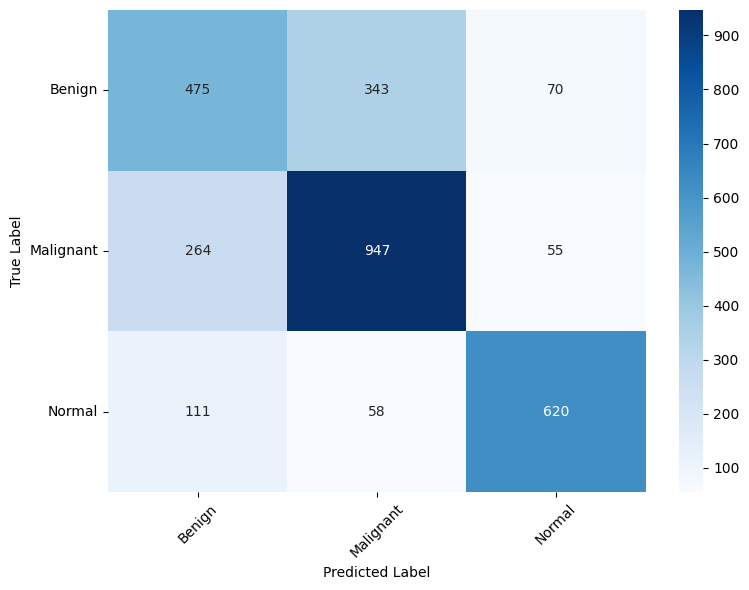


Raw cascade confusion matrix:
Classes: ['Benign', 'Malignant', 'Normal']
[[475 343  70]
 [264 947  55]
 [111  58 620]]

Benign-vs-Malignant target metric on the cascade (n=2154): 66.02%
(v5's equivalent number was 68.15% -- v4 did not print this metric, it was added in v5)
done1


In [19]:
# ==========================================================
# FULL 3-CLASS CASCADE EVALUATION ON THE TEST SET
# ==========================================================
print("start")

full_test_generator = ResNetWaveletGenerator(
    test_dir, num_classes=3, shuffle=False, labeled=True, augment=False
)
class_names_3way = full_test_generator.class_names   # sorted: Benign, Malignant, Normal
true_classes_test = full_test_generator.labels

# Stage 1: Normal vs Abnormal on every test image
stage1_full_test_generator = ResNetWaveletGenerator(
    test_dir, num_classes=2, shuffle=False, labeled=True,
    label_remap=stage1_label_remap, augment=False
)
stage1_preds_full = stage1_model.predict(stage1_full_test_generator, verbose=1)
stage1_pred_is_abnormal = np.argmax(stage1_preds_full, axis=1) == 1   # True = predicted Abnormal

# Stage 2: Benign vs Malignant, only on images Stage 1 called Abnormal
final_predictions = np.array([class_names_3way.index("Normal")] * len(full_test_generator.filepaths))

abnormal_idx = np.where(stage1_pred_is_abnormal)[0]
if len(abnormal_idx) > 0:
    abnormal_filepaths = set(np.array(full_test_generator.filepaths)[abnormal_idx].tolist())
    stage2_cascade_generator = ResNetWaveletGenerator(
        test_dir, num_classes=2, shuffle=False, labeled=True,
        allowed_classes=["Benign", "Malignant"], label_remap=stage2_label_remap,
        include_filepaths=abnormal_filepaths, augment=False
    )
    # NOTE: this generator only walks Benign/Malignant subfolders, so any Stage-1-flagged-Abnormal
    # image whose TRUE label is Normal (a Stage 1 false positive) is invisible to it by construction.
    # We handle that below by mapping cascade predictions back onto the original file order.
    stage2_cascade_preds = stage2_model.predict(stage2_cascade_generator, verbose=1)
    stage2_cascade_pred_classes = np.argmax(stage2_cascade_preds, axis=1)

    filepath_to_final_idx = {fp: i for i, fp in enumerate(full_test_generator.filepaths)}
    for fp, pred in zip(stage2_cascade_generator.filepaths, stage2_cascade_pred_classes):
        final_class_name = "Benign" if pred == 0 else "Malignant"
        final_predictions[filepath_to_final_idx[fp]] = class_names_3way.index(final_class_name)

    # Any image Stage 1 flagged Abnormal but whose TRUE label is Normal never appears in
    # stage2_cascade_generator (allowed_classes excludes Normal) -- it still needs a final
    # prediction. Since Stage 2 was never trained to recognize Normal, we fall back to whichever
    # of Benign/Malignant Stage 2 leans toward for these -- run them through Stage 2 without the
    # class restriction using a small custom loop.
    normal_but_flagged_abnormal = [
        fp for i, fp in zip(abnormal_idx, np.array(full_test_generator.filepaths)[abnormal_idx])
        if fp not in set(stage2_cascade_generator.filepaths)
    ]
    if normal_but_flagged_abnormal:
        fallback_generator = ResNetWaveletGenerator(
            test_dir, num_classes=3, shuffle=False, labeled=False, augment=False,
            include_filepaths=set(normal_but_flagged_abnormal)
        )
        for b in range(len(fallback_generator)):
            batch_x, _ = fallback_generator[b]
            fb_preds = stage2_model.predict_on_batch(batch_x)
            fb_pred_classes = np.argmax(fb_preds, axis=1)
            start = b * fallback_generator.batch_size
            for j, pred in enumerate(fb_pred_classes):
                fp = fallback_generator.filepaths[start + j]
                final_class_name = "Benign" if pred == 0 else "Malignant"
                final_predictions[filepath_to_final_idx[fp]] = class_names_3way.index(final_class_name)
        print(f"({len(normal_but_flagged_abnormal)} true-Normal images that Stage 1 misclassified as "
              f"Abnormal were routed through Stage 2's fallback path.)")

print("\nCascade Classification Report (full 3-class test set):")
print(classification_report(true_classes_test, final_predictions, target_names=class_names_3way))

cm_cascade = confusion_matrix(true_classes_test, final_predictions)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_cascade, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_3way, yticklabels=class_names_3way)
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.xticks(rotation=45); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("Cascade_confusion_matrix_test_v6.pdf", format='pdf', bbox_inches='tight')
plt.show()

print("\nRaw cascade confusion matrix:")
print("Classes:", class_names_3way)
print(cm_cascade)

b_idx3 = class_names_3way.index("Benign")
m_idx3 = class_names_3way.index("Malignant")
pair_mask = np.isin(true_classes_test, [b_idx3, m_idx3])
pair_acc = float(np.mean(true_classes_test[pair_mask] == final_predictions[pair_mask]))
print(f"\nBenign-vs-Malignant target metric on the cascade (n={int(pair_mask.sum())}): {pair_acc*100:.2f}%")
print("(v5's equivalent number was 68.15% -- v4 did not print this metric, it was added in v5)")

print("done1")


## Notes & tunable hyperparameters (v6)

- **`STAGE1_CONFIDENCE_FOR_STAGE2_POOL` (0.60)** -- controls how much Stage 2's self-training pool
  trusts Stage 1. Raise it (e.g. 0.75) if Stage 2 ends up self-training on too many actually-Normal
  images that slipped through; lower it if Stage 2's pool is too small to matter.
- **`FINETUNE_UNFREEZE_LAST_N_STAGE2` (20)** -- the whole point of the cascade is giving this specific
  boundary its own dedicated capacity; if Stage 2 standalone (Benign/Malignant-only) accuracy is still
  weak, this is the first thing to raise further (e.g. 30, or unfreeze the whole backbone) since there's
  no Normal class at risk of being destabilized by it anymore.
- **Read Stage 1's and Stage 2's *standalone* evaluation cells before the final cascade cell.** If the
  cascade result disappoints, those two cells tell you which stage to blame: if Stage 1's Normal-vs-
  Abnormal report is weak, more of the error is coming from routing mistakes upstream of Stage 2 ever
  getting a chance; if Stage 2's own Benign/Malignant report (on the clean, non-cascaded test subset) is
  still weak, the dedicated-specialist idea itself needs more work (more data, higher resolution, a
  different architecture) rather than more cascade plumbing.
- **This is a genuinely different lever than v3-v5**, not a hyperparameter change -- if it *doesn't* beat
  v4's 70.09%, that's real evidence the Benign/Malignant confusion in this dataset may be closer to a
  data-quality or task-difficulty ceiling than an architecture problem, and the next productive step
  would likely be inspecting misclassified images directly rather than further model changes.
